# Movie Sentiment Analysis

Dataset link : https://ai.stanford.edu/~amaas/data/sentiment/

Kaggle Dataset link : https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [1]:
import pandas as pd

In [2]:
url_path = "data/IMDB Dataset.csv"
df_original = pd.read_csv(url_path)

In [3]:
df = df_original

In [4]:
df = df_original.copy(deep=True)

# Basic Info

In [5]:
print(df.columns.to_list())

['review', 'sentiment']


In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [8]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [9]:
50000 - 49582 # no of duplicate rows

418

In [10]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

# Descriptive Stats

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Summary Statistics
df['review_char_len'] = df['review'].apply(len)
df['review_word_len'] = df['review'].apply(lambda x: len(x.split()))

# Descriptive stats
print(df[['review_char_len','review_word_len']].describe())

       review_char_len  review_word_len
count     50000.000000     50000.000000
mean       1309.431020       231.156940
std         989.728014       171.343997
min          32.000000         4.000000
25%         699.000000       126.000000
50%         970.000000       173.000000
75%        1590.250000       280.000000
max       13704.000000      2470.000000


In [13]:
# does too short or too long reviews has any relation to sentiment

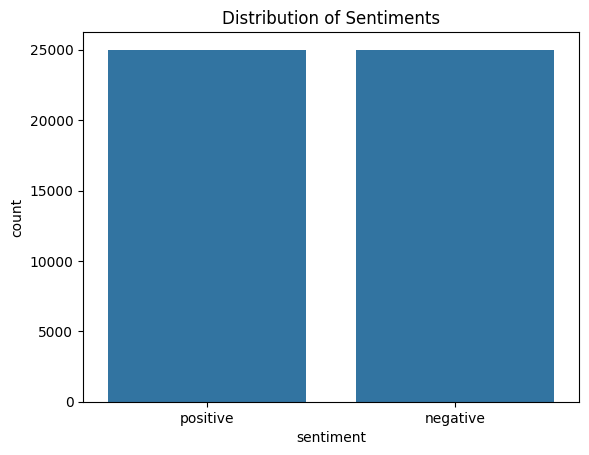

In [14]:
# Sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiments")
plt.show()

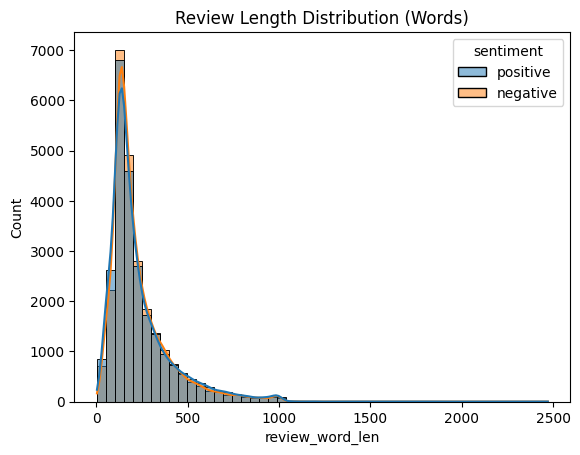

In [15]:
# Histogram of review word lengths
sns.histplot(data=df, x='review_word_len', bins=50, hue='sentiment', kde=True)
plt.title("Review Length Distribution (Words)")
plt.show()

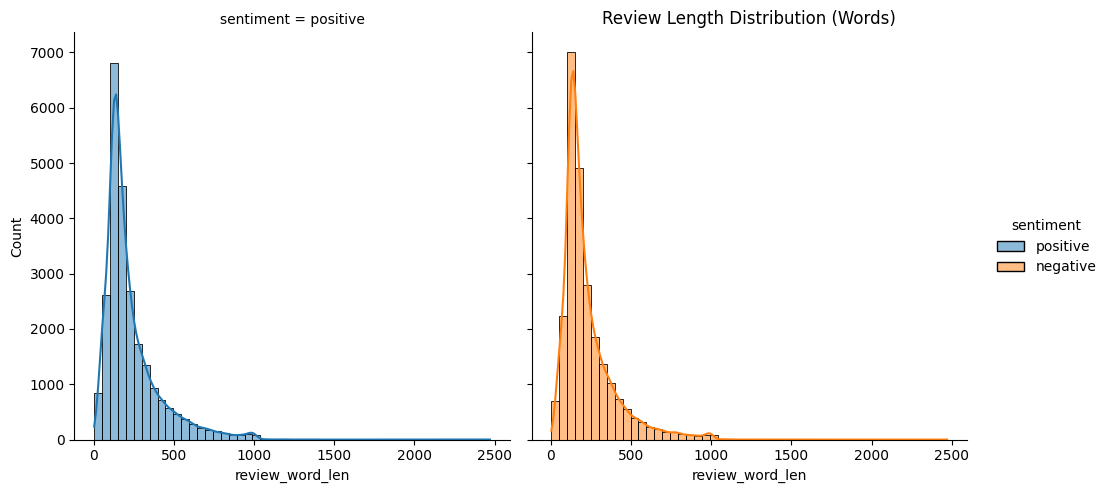

In [16]:
# Histogram of review word lengths
sns.displot(data=df, x='review_word_len', bins=50, col="sentiment", hue='sentiment', kde=True)
plt.title("Review Length Distribution (Words)")
plt.show()

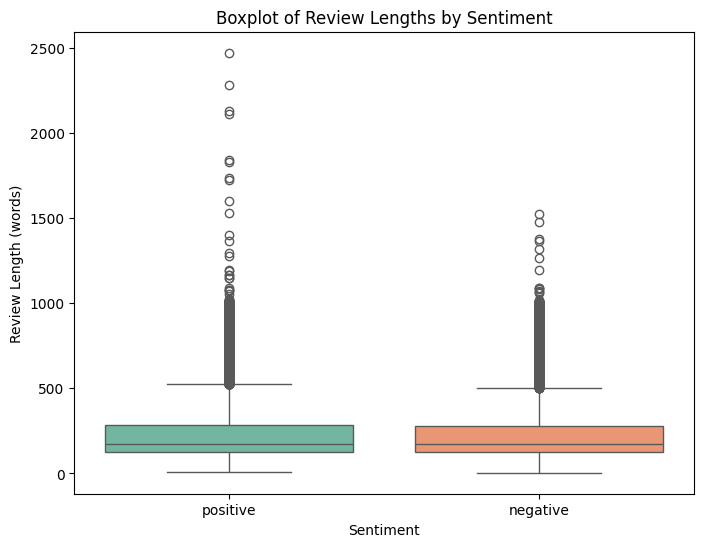

In [17]:
# Boxplot of Review Length by Sentiment
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

# Removing outliers

In [18]:
import numpy as np

In [19]:
# Calculate Q1, Q3, and IQR
Q1 = df['review_word_len'].quantile(0.25)
Q3 = df['review_word_len'].quantile(0.75)
IQR = Q3 - Q1

In [20]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -105.0
Upper Bound: 511.0


In [21]:
outliers = df[(df['review_word_len'] < lower_bound) | (df['review_word_len'] > upper_bound)]
# DF of outliers

In [22]:
print("Number of outliers:", outliers.shape[0])

Number of outliers: 3708


In [23]:
50000-3708

46292

In [24]:
# FE STEP
df_clean_from_iqr = df[(df['review_word_len'] >= lower_bound) & (df['review_word_len'] <= upper_bound)]
print("Orignal Data :", df.shape[0])
print("Cleaned Data :", df_clean_from_iqr.shape[0])

Orignal Data : 50000
Cleaned Data : 46292


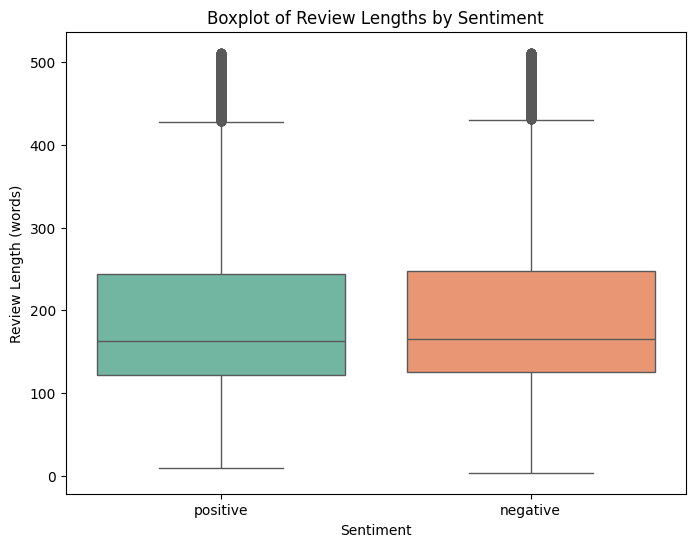

In [25]:
# Boxplot of Review Length by Sentiment
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df_clean_from_iqr, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

In [26]:
df_clean_from_iqr.head()

,review,sentiment,review_char_len,review_word_len
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


In [27]:
# how many positive words in a positive case -->
# how many negative words in a negative case -->

# Most common Words (Positive vs Negative)

In [29]:
# !pip install nltk

In [ ]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

In [31]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\scl\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [32]:
len(stop_words)

198

In [34]:
type(stop_words)

set

In [35]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [40]:
# remove symbols from the reviews (not alphabet), br

def preprocess_text(text):
    # select only alphabet / extract only alphabet
    words = re.findall(r'\b[a-z]+\b', text.lower())
    # print(words)
    return [w for w in words if w not in stop_words and w!="br"]
    

In [37]:
preprocess_text("<br > hello how are you !#$ 123")

['br', 'hello', 'how', 'are', 'you']


['hello']

In [38]:
preprocess_text("<br > the movie was great")

['br', 'the', 'movie', 'was', 'great']


['movie', 'great']

In [ ]:
# Separate reviews by sentiment 
pos_reviews = df[df['sentiment']=="positive"]['review'].apply(preprocess_text)
neg_reviews = df[df['sentiment']=="negative"]['review'].apply(preprocess_text)

In [43]:
type(pos_reviews)

pandas.Series

In [45]:
pos_reviews.shape

(25000,)

In [46]:
# Flatten lists
pos_words = [word for review in pos_reviews for word in review]
neg_words = [word for review in neg_reviews for word in review]

In [50]:
# Get most common words
pos_common = Counter(pos_words).most_common(30)
neg_common = Counter(neg_words).most_common(30)

In [51]:
print("Top 30 Positive Words:", pos_common)
print("Top 30 Negative Words:", neg_common)

Top 30 Positive Words: [('film', 42110), ('movie', 37854), ('one', 27320), ('like', 17714), ('good', 15025), ('great', 12964), ('story', 12934), ('time', 12752), ('well', 12729), ('see', 12276), ('also', 10793), ('really', 10739), ('would', 10595), ('even', 9617), ('first', 9230), ('much', 9201), ('people', 8719), ('love', 8692), ('best', 8510), ('get', 8285), ('life', 8137), ('way', 7865), ('many', 7627), ('films', 7601), ('made', 7351), ('think', 7208), ('two', 7161), ('characters', 7103), ('movies', 6996), ('character', 6925)]
Top 30 Negative Words: [('movie', 50117), ('film', 37595), ('one', 26283), ('like', 22458), ('even', 15254), ('good', 14728), ('bad', 14726), ('would', 14007), ('time', 12358), ('really', 12355), ('see', 10753), ('story', 10185), ('get', 10136), ('much', 10117), ('people', 9469), ('make', 9355), ('could', 9300), ('made', 8801), ('well', 8539), ('first', 8353), ('movies', 8313), ('plot', 8214), ('acting', 8087), ('way', 7780), ('characters', 7353), ('watch', 72

In [52]:
from sklearn.feature_extraction.text import CountVectorizer

In [53]:
# CountVectorizer
# (2,2) -> 2 .. 2 --> bi-gram
# (3,3) -> 3 .. 3 --> tri-gram
# (2,3) -> 2 3 --> [bi + tri]
# (1,3) -> 1 2 3 --> [uni + bi + tri]


In [58]:
def get_top_ngrams(words_list, ngram_range=(2,2), top_n=20):
    vec = CountVectorizer(ngram_range=ngram_range)
    bag = vec.fit_transform([' '.join(words_list)])
    sum_words = bag.sum(axis=0)
    # print(sum_words)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    sorted_words = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return sorted_words[:top_n]


In [60]:
# Top bigrams
print("Top Positive Bigrams:", get_top_ngrams(pos_words, (2,2)))
print("Top Negative Bigrams:", get_top_ngrams(neg_words, (2,2)))

Top Positive Bigrams: [('one best', np.int64(1680)), ('even though', np.int64(1099)), ('ever seen', np.int64(976)), ('first time', np.int64(960)), ('new york', np.int64(855)), ('special effects', np.int64(806)), ('see movie', np.int64(784)), ('must see', np.int64(778)), ('real life', np.int64(761)), ('years ago', np.int64(741)), ('good movie', np.int64(737)), ('well done', np.int64(727)), ('great movie', np.int64(703)), ('year old', np.int64(684)), ('sci fi', np.int64(623)), ('low budget', np.int64(594)), ('pretty good', np.int64(581)), ('watch movie', np.int64(578)), ('great film', np.int64(569)), ('saw movie', np.int64(567))]
Top Negative Bigrams: [('ever seen', np.int64(1734)), ('special effects', np.int64(1443)), ('waste time', np.int64(1437)), ('looks like', np.int64(1234)), ('low budget', np.int64(1229)), ('much better', np.int64(1009)), ('one worst', np.int64(964)), ('look like', np.int64(945)), ('bad movie', np.int64(927)), ('year old', np.int64(914)), ('even though', np.int64(

In [61]:
# Top trigrams
print("Top Positive Trigrams:", get_top_ngrams(pos_words, (3,3)))
print("Top Negative Trigrams:", get_top_ngrams(neg_words, (3,3)))

Top Positive Trigrams: [('new york city', np.int64(195)), ('world war ii', np.int64(167)), ('one best movies', np.int64(144)), ('based true story', np.int64(135)), ('movie ever seen', np.int64(134)), ('one best films', np.int64(132)), ('first time saw', np.int64(115)), ('movies ever seen', np.int64(112)), ('films ever made', np.int64(99)), ('well worth watching', np.int64(95)), ('first saw movie', np.int64(94)), ('seen long time', np.int64(91)), ('highly recommend movie', np.int64(87)), ('international film festival', np.int64(83)), ('would love see', np.int64(81)), ('films ever seen', np.int64(77)), ('movies ever made', np.int64(75)), ('first saw film', np.int64(73)), ('many years ago', np.int64(73)), ('best movie ever', np.int64(72))]
Top Negative Trigrams: [('worst movie ever', np.int64(459)), ('movie ever seen', np.int64(394)), ('one worst movies', np.int64(311)), ('worst movies ever', np.int64(282)), ('movies ever seen', np.int64(268)), ('worst film ever', np.int64(202)), ('waste 

In [ ]:
# Top tetragrams|
print("Top Positive tetragrams:", get_top_ngrams(pos_words, (4,4)))
print("Top Negative tetragrams:", get_top_ngrams(neg_words, (4,4)))

Top Positive Trigrams: [('one best movies ever', np.int64(51)), ('one best movies seen', np.int64(36)), ('best movie ever seen', np.int64(32)), ('one best films seen', np.int64(31)), ('vote eight title brazil', np.int64(30)), ('vote seven title brazil', np.int64(28)), ('one best films ever', np.int64(28)), ('well written well acted', np.int64(26)), ('tony hawk pro skater', np.int64(26)), ('best movies ever seen', np.int64(24)), ('oz greatest show ever', np.int64(24)), ('greatest show ever mad', np.int64(24)), ('show ever mad full', np.int64(24)), ('toronto international film festival', np.int64(23)), ('movie based true story', np.int64(23)), ('ever mad full stop', np.int64(23)), ('mad full stop oz', np.int64(23)), ('full stop oz greatest', np.int64(23)), ('stop oz greatest show', np.int64(23)), ('postman always rings twice', np.int64(21))]
Top Negative Trigrams: [('worst movie ever seen', np.int64(258)), ('one worst movies ever', np.int64(242)), ('worst movies ever seen', np.int64(181)

In [ ]:
# !pip install wordcloud

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
from wordcloud import WordCloud

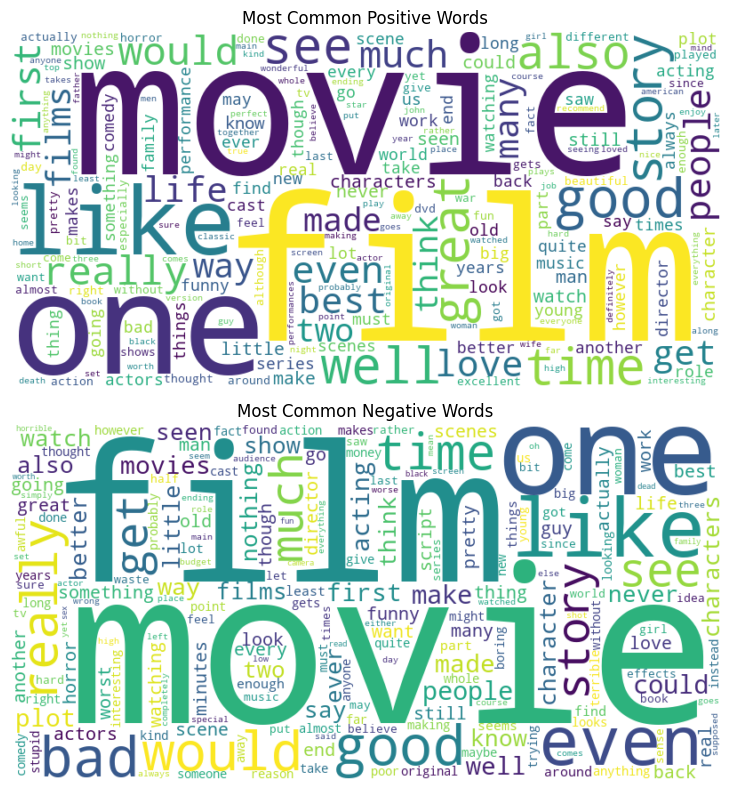

In [65]:
# Get most common words
pos_common_300 = Counter(pos_words).most_common(300)
neg_common_300 = Counter(neg_words).most_common(300)

pos_word_dict = dict(pos_common_300)
neg_word_dict = dict(neg_common_300)

# Generate a word cloud for positive words
pos_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(pos_word_dict)

# Generate a word cloud for negative words
neg_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(neg_word_dict)



# Plot the word clouds
plt.figure(figsize=(20, 8))

plt.subplot(2, 1, 1)
plt.imshow(pos_wordcloud, interpolation='bilinear')
plt.title('Most Common Positive Words')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(neg_wordcloud, interpolation='bilinear')
plt.title('Most Common Negative Words')
plt.axis('off')

plt.tight_layout()
plt.show()

# Assignment

In [ ]:
# Assignment, Based on n-gram validate if the sentiment is correct or not
# review[1] = "movie was great, but it can be better" | "Positive"
# "Positive" | "Postive" --> 1
# "Negative" | "Positive" -> 0
# "Negative" | "Negative" --> 1

In [ ]:
"movie great" -> postive / negative
"great better" -> positive / negative

In [66]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [67]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\scl\AppData\Roaming\nltk_data...


True

In [68]:
analyzer = SentimentIntensityAnalyzer()

In [69]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return "good"
    elif score <= -0.05:
        return "bad"
    else:
        return "neutral"

In [70]:
get_sentiment("movie great")

'good'

In [72]:
get_sentiment("bad movie")

'bad'

In [73]:
get_sentiment("how are you")

'neutral'

In [74]:
get_sentiment("movie was okay")

'good'

In [75]:
get_sentiment("ridiculous movie")

'bad'

In [ ]:
# % of correctness / incorrect

# inferential Stats

In [76]:
# Goal 1 :
# Check if review len differs significantly between positive and negative reviews

# H0 : Average review length (in words) is the same for positive and negative review
# H1 : Average review length (in words) is different between positive and negative reviews.

from scipy.stats import ttest_ind

pos_lengths = df[df['sentiment'] == 'positive']['review_word_len']
neg_lengths = df[df['sentiment'] == 'negative']['review_word_len']

t_stat, p_value = ttest_ind(pos_lengths, neg_lengths, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Calculate means and median for interpretation
print("Mean words (positive reviews):", pos_lengths.mean())
print("Mean words (negative reviews):", neg_lengths.mean())


print("Median words (positive reviews):", pos_lengths.median())
print("Median words (negative reviews):", neg_lengths.median())


if p_value < 0.05 :
    print(f"We reject H0 ({p_value} < 0.05), average review length is different for positive and negative sentiment")
else :
    print("Fail to reject H0")

T-statistic: 2.208670012690372
P-value: 0.027202144656625855
Mean words (positive reviews): 232.84932
Mean words (negative reviews): 229.46456
Median words (positive reviews): 172.0
Median words (negative reviews): 174.0
We reject H0 (0.027202144656625855 < 0.05), average review length is different for positive and negative sentiment


In [82]:
df_subset = df.sample(n=1000, random_state=200)

pos_lengths_sub = df_subset[df_subset['sentiment'] == 'positive']['review_word_len']
neg_lengths_sub = df_subset[df_subset['sentiment'] == 'negative']['review_word_len']

print(len(pos_lengths_sub), len(neg_lengths_sub))

t_stat_sub, p_value_sub = ttest_ind(pos_lengths_sub, neg_lengths_sub, equal_var=False)

print("T-statistic:", t_stat_sub)
print("P-value:", p_value_sub)

# Calculate means and median for interpretation
print("Mean words (positive reviews):", pos_lengths_sub.mean())
print("Mean words (negative reviews):", neg_lengths_sub.mean())

print("Median words (positive reviews):", pos_lengths_sub.median())
print("Median words (negative reviews):", neg_lengths_sub.median())

if p_value_sub < 0.05 :
    print(f"We reject H0 ({p_value_sub} < 0.05), average review length is different for positive and negative sentiment")
else :
    print("Fail to reject H0")


501 499
T-statistic: 1.1245846825884633
P-value: 0.2610490462372629
Mean words (positive reviews): 233.74850299401197
Mean words (negative reviews): 220.9438877755511
Median words (positive reviews): 173.0
Median words (negative reviews): 167.0
Fail to reject H0


In [83]:
# Chi-Square Test of Independence
# H0 : Average review length (in words) is the same for positive and negative review
# H1 : Average review length (in words) is different between positive and negative reviews.

# Categorial
# word length : Not categorical
# Review length category → categorical (short, long)

# Sentiment → categorical (positive, negative)

df_subset['review_length_cat'] = df_subset['review_word_len'].apply(lambda x: 'short' if x <= 100 else 'long')

In [84]:
contingency = pd.crosstab(df_subset['review_length_cat'], df_subset['sentiment'])
print("Contingency Table:", contingency)


Contingency Table: sentiment          negative  positive
review_length_cat                    
long                    449       433
short                    50        68


In [85]:
from scipy.stats import chi2_contingency

In [86]:
chi2, p, _ , _ = chi2_contingency(contingency)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)

if p < 0.05 :
    print(f"We reject H0 ({p} < 0.05), average review length is different for positive and negative sentiment")
else :
    print("Fail to reject H0")


Chi-Square Statistic: 2.700265384250744
P-value: 0.10033154454630791
Fail to reject H0


# Conclusion : Average review length (in words) is the same for positive and negative review